In [1]:
library(tidyverse)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.1.5
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.0     v tibble    3.3.0
v lubridate 1.9.5     v tidyr     1.3.1
v purrr     1.2.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
d <- read_tsv(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/results/clonal_table/clonal_metrics.tsv",
  show_col_types = FALSE
) |>
  mutate(completo = n_secuencias >= 0.99 * profundidad)

d %>% head()

escenario,profundidad,n_secuencias,n_clones,singletons,proporcion_singletons,clon_mayor,completo
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
A,100,100,100,100,1.0000000,1,TRUE
A,200,200,197,194,0.9847716,2,TRUE
A,400,400,394,388,0.9847716,2,TRUE
A,800,800,770,747,0.9701299,5,TRUE
A,1600,1600,1522,1472,0.9671485,6,TRUE
A,3200,3200,2983,2840,0.9520617,15,TRUE


In [3]:
fin <- d |>
  filter(completo) |>
  slice_max(profundidad, by = escenario) |>
  left_join(summarise(d, trunco = any(!completo), .by = escenario), by = "escenario") |>
  mutate(etiqueta = paste0(
    escenario, ".", formatC(n_clones, big.mark = ".", decimal.mark = ",", format = "d"),
    " clones"
  ))

<theme> List of 1
 $ text: <ggplot2::element_text>
  ..@ family       : chr "Arial Unicode MS"
  ..@ face         : NULL
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : NULL
  ..@ size         : NULL
  ..@ hjust        : NULL
  ..@ vjust        : NULL
  ..@ angle        : NULL
  ..@ lineheight   : NULL
  ..@ margin       : NULL
  ..@ debug        : NULL
  ..@ inherit.blank: logi FALSE
 @ complete: logi FALSE
 @ validate: logi TRUE

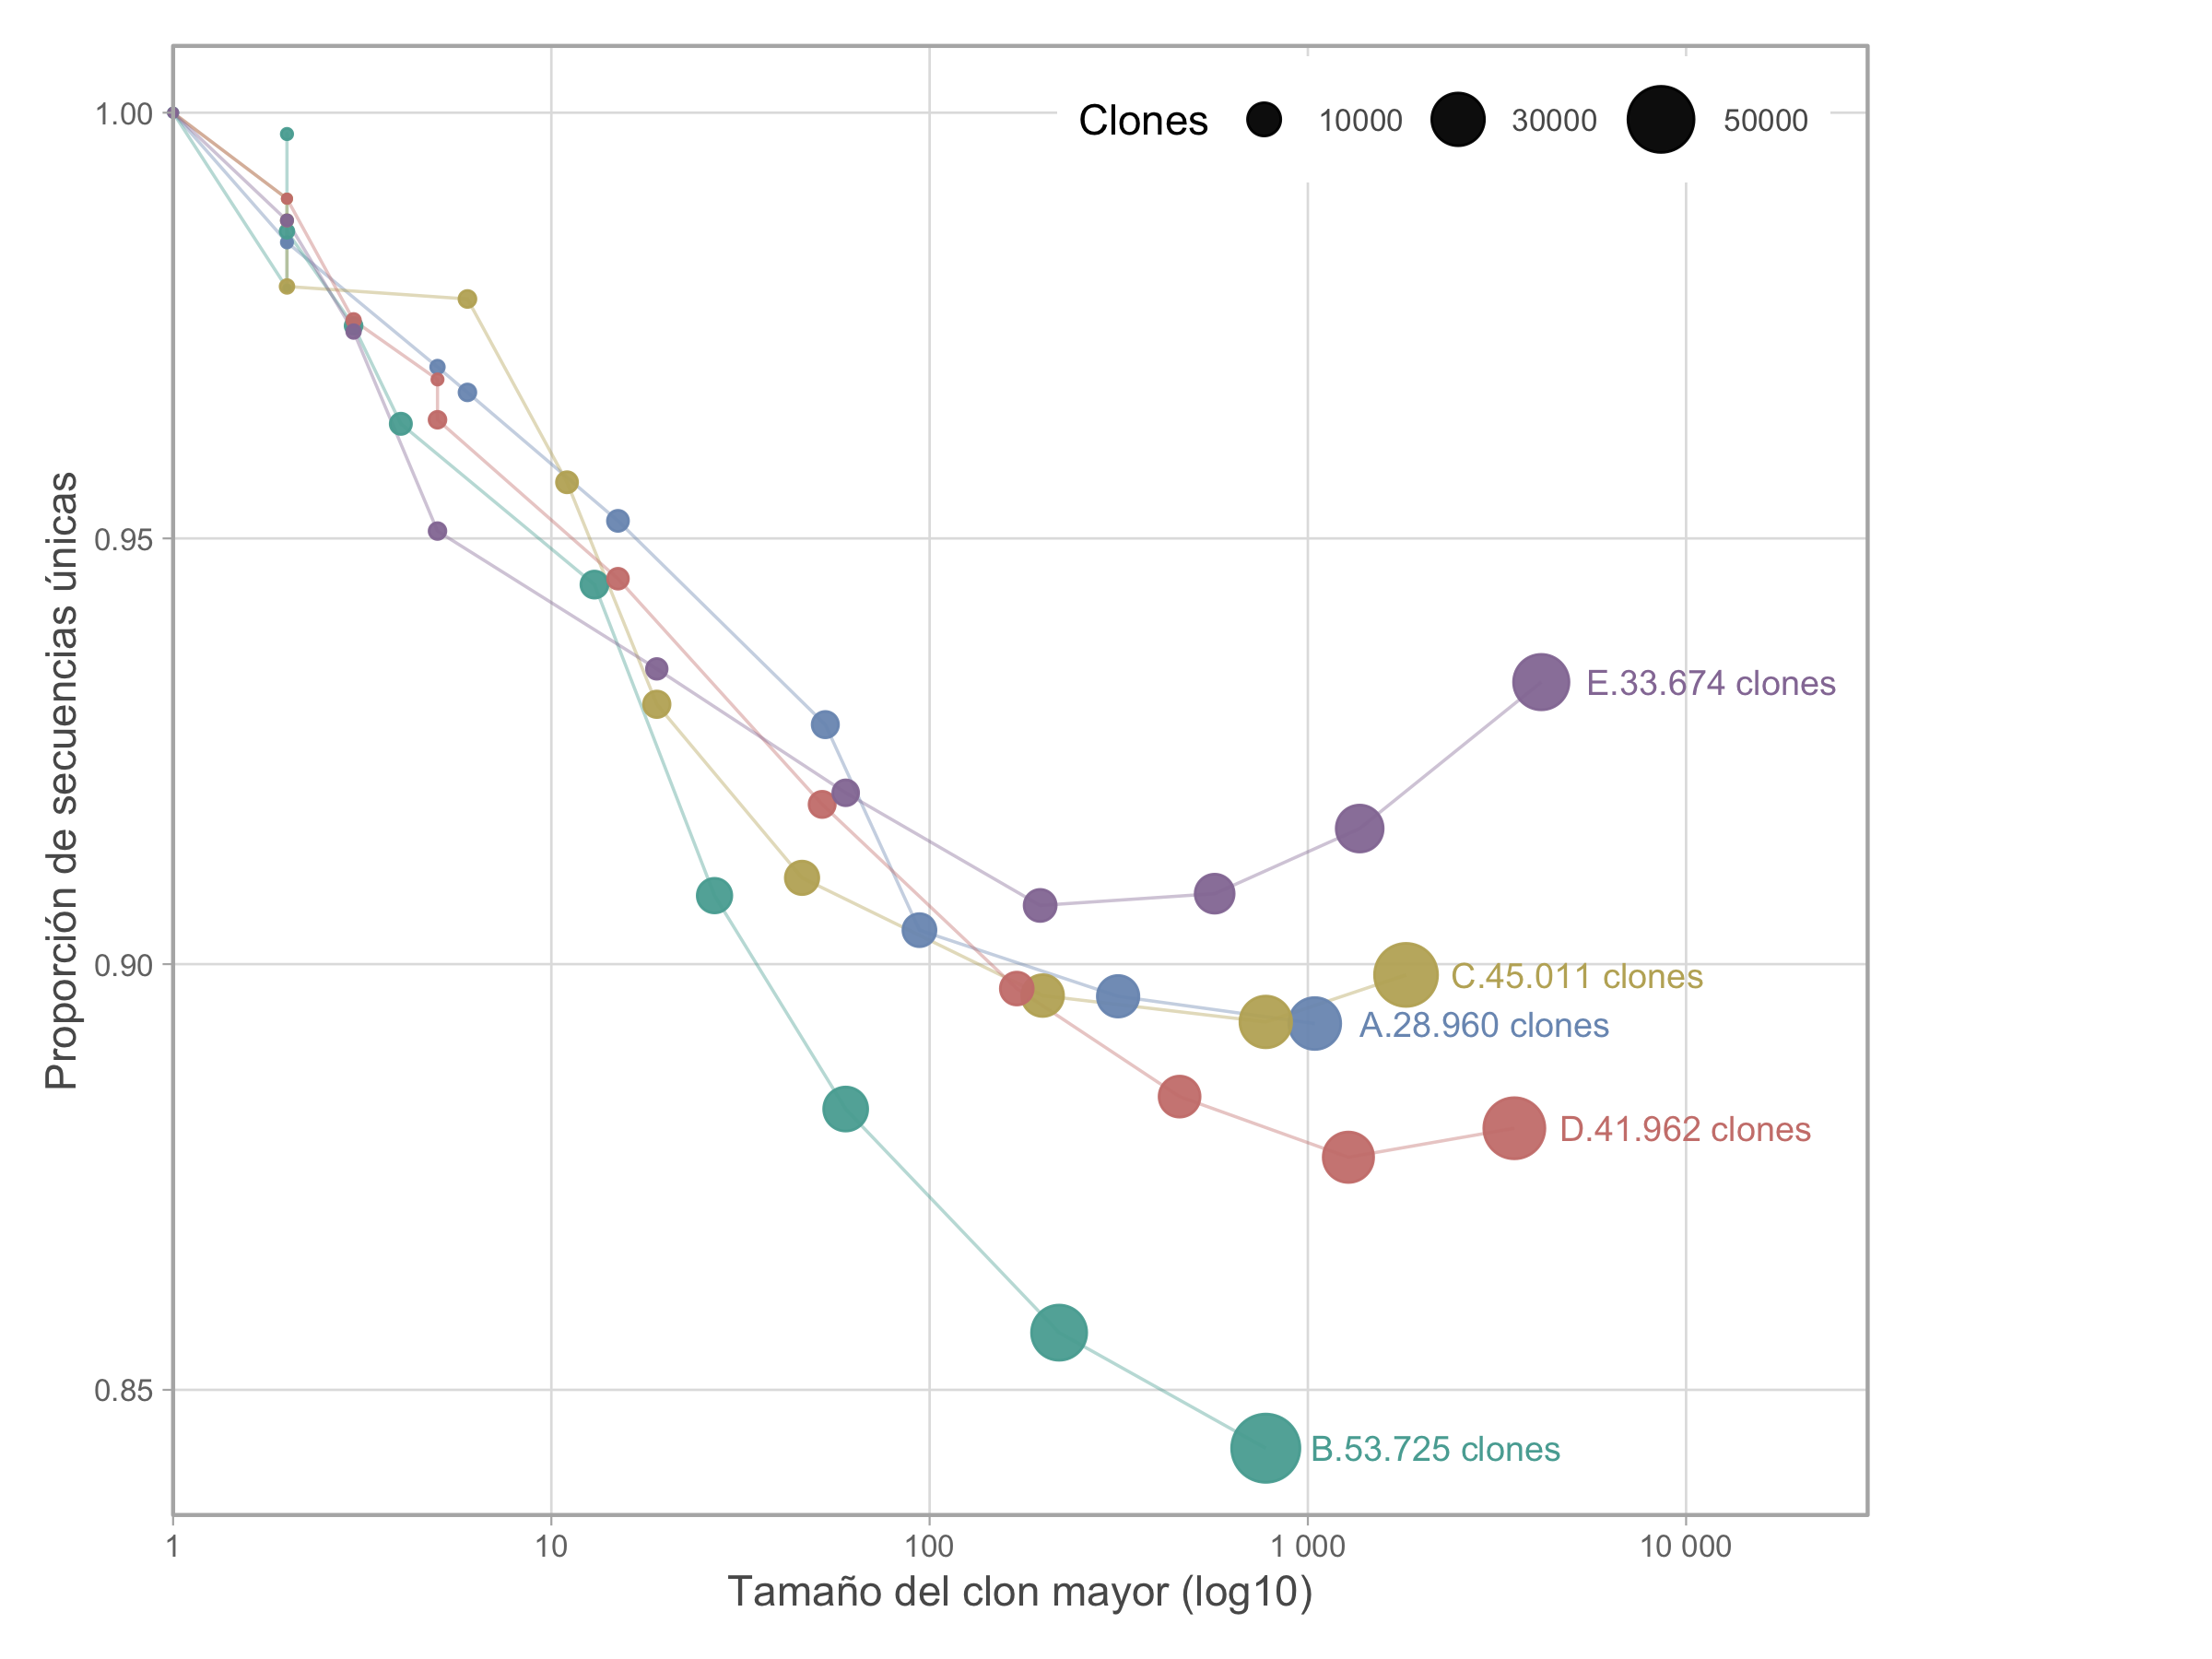

In [14]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)

colors <- c(A = "#7B98BE", B = "#58ABA2", C = "#BFAF66", D = "#CD817C", E = "#957BA4")

theme(text = element_text(family = "Arial Unicode MS"))
ggplot(d, aes(x = clon_mayor, y = proporcion_singletons, color = escenario)) +
  geom_line(data = ~ filter(.x, completo), linewidth = 0.4, alpha = 0.4) +
  geom_point(data = ~ filter(.x, completo), aes(size = n_clones), alpha = 0.95) +
  geom_text(
    data = fin,
    aes(label = etiqueta),
    hjust = 0,
    nudge_x = 0.12,
    size = 3.2,
  ) +
  scale_x_log10(
    breaks = c(1, 10, 100, 1000, 10000),
    labels = c("1", "10", "100", "1 000", "10 000"),
    limits = c(1, 10000),
    expand = expansion(mult = c(0, 0.12))
  ) +
  scale_size(
    range = c(0.5, 8),
    breaks = c(10000, 30000, 50000),
  ) +
  scale_color_manual(values = colors, guide = "none") +
  coord_cartesian(clip = "off") +
  labs(
    x = "Tamaño del clon mayor (log10)",
    y = "Proporción de secuencias únicas",
    size = "Clones"
  ) +
  theme_light() +
  theme(
    plot.title = element_text(size = 9, colour = "grey35", hjust = 0, margin = margin(b = 14)),
    plot.margin = margin(12, 90, 12, 12),
    axis.title = element_text(colour = "grey35"),
    axis.text = element_text(size = 8, colour = "grey45"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey88", linewidth = 0.3),
    legend.position = "inside",
    legend.position.inside = c(0.75, 0.95),
    legend.direction = "horizontal",
    legend.text = element_text(size = 8, colour = "grey35"),
  )

  


<theme> List of 1
 $ text: <ggplot2::element_text>
  ..@ family       : chr "Arial Unicode MS"
  ..@ face         : NULL
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : NULL
  ..@ size         : NULL
  ..@ hjust        : NULL
  ..@ vjust        : NULL
  ..@ angle        : NULL
  ..@ lineheight   : NULL
  ..@ margin       : NULL
  ..@ debug        : NULL
  ..@ inherit.blank: logi FALSE
 @ complete: logi FALSE
 @ validate: logi TRUE

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`)."


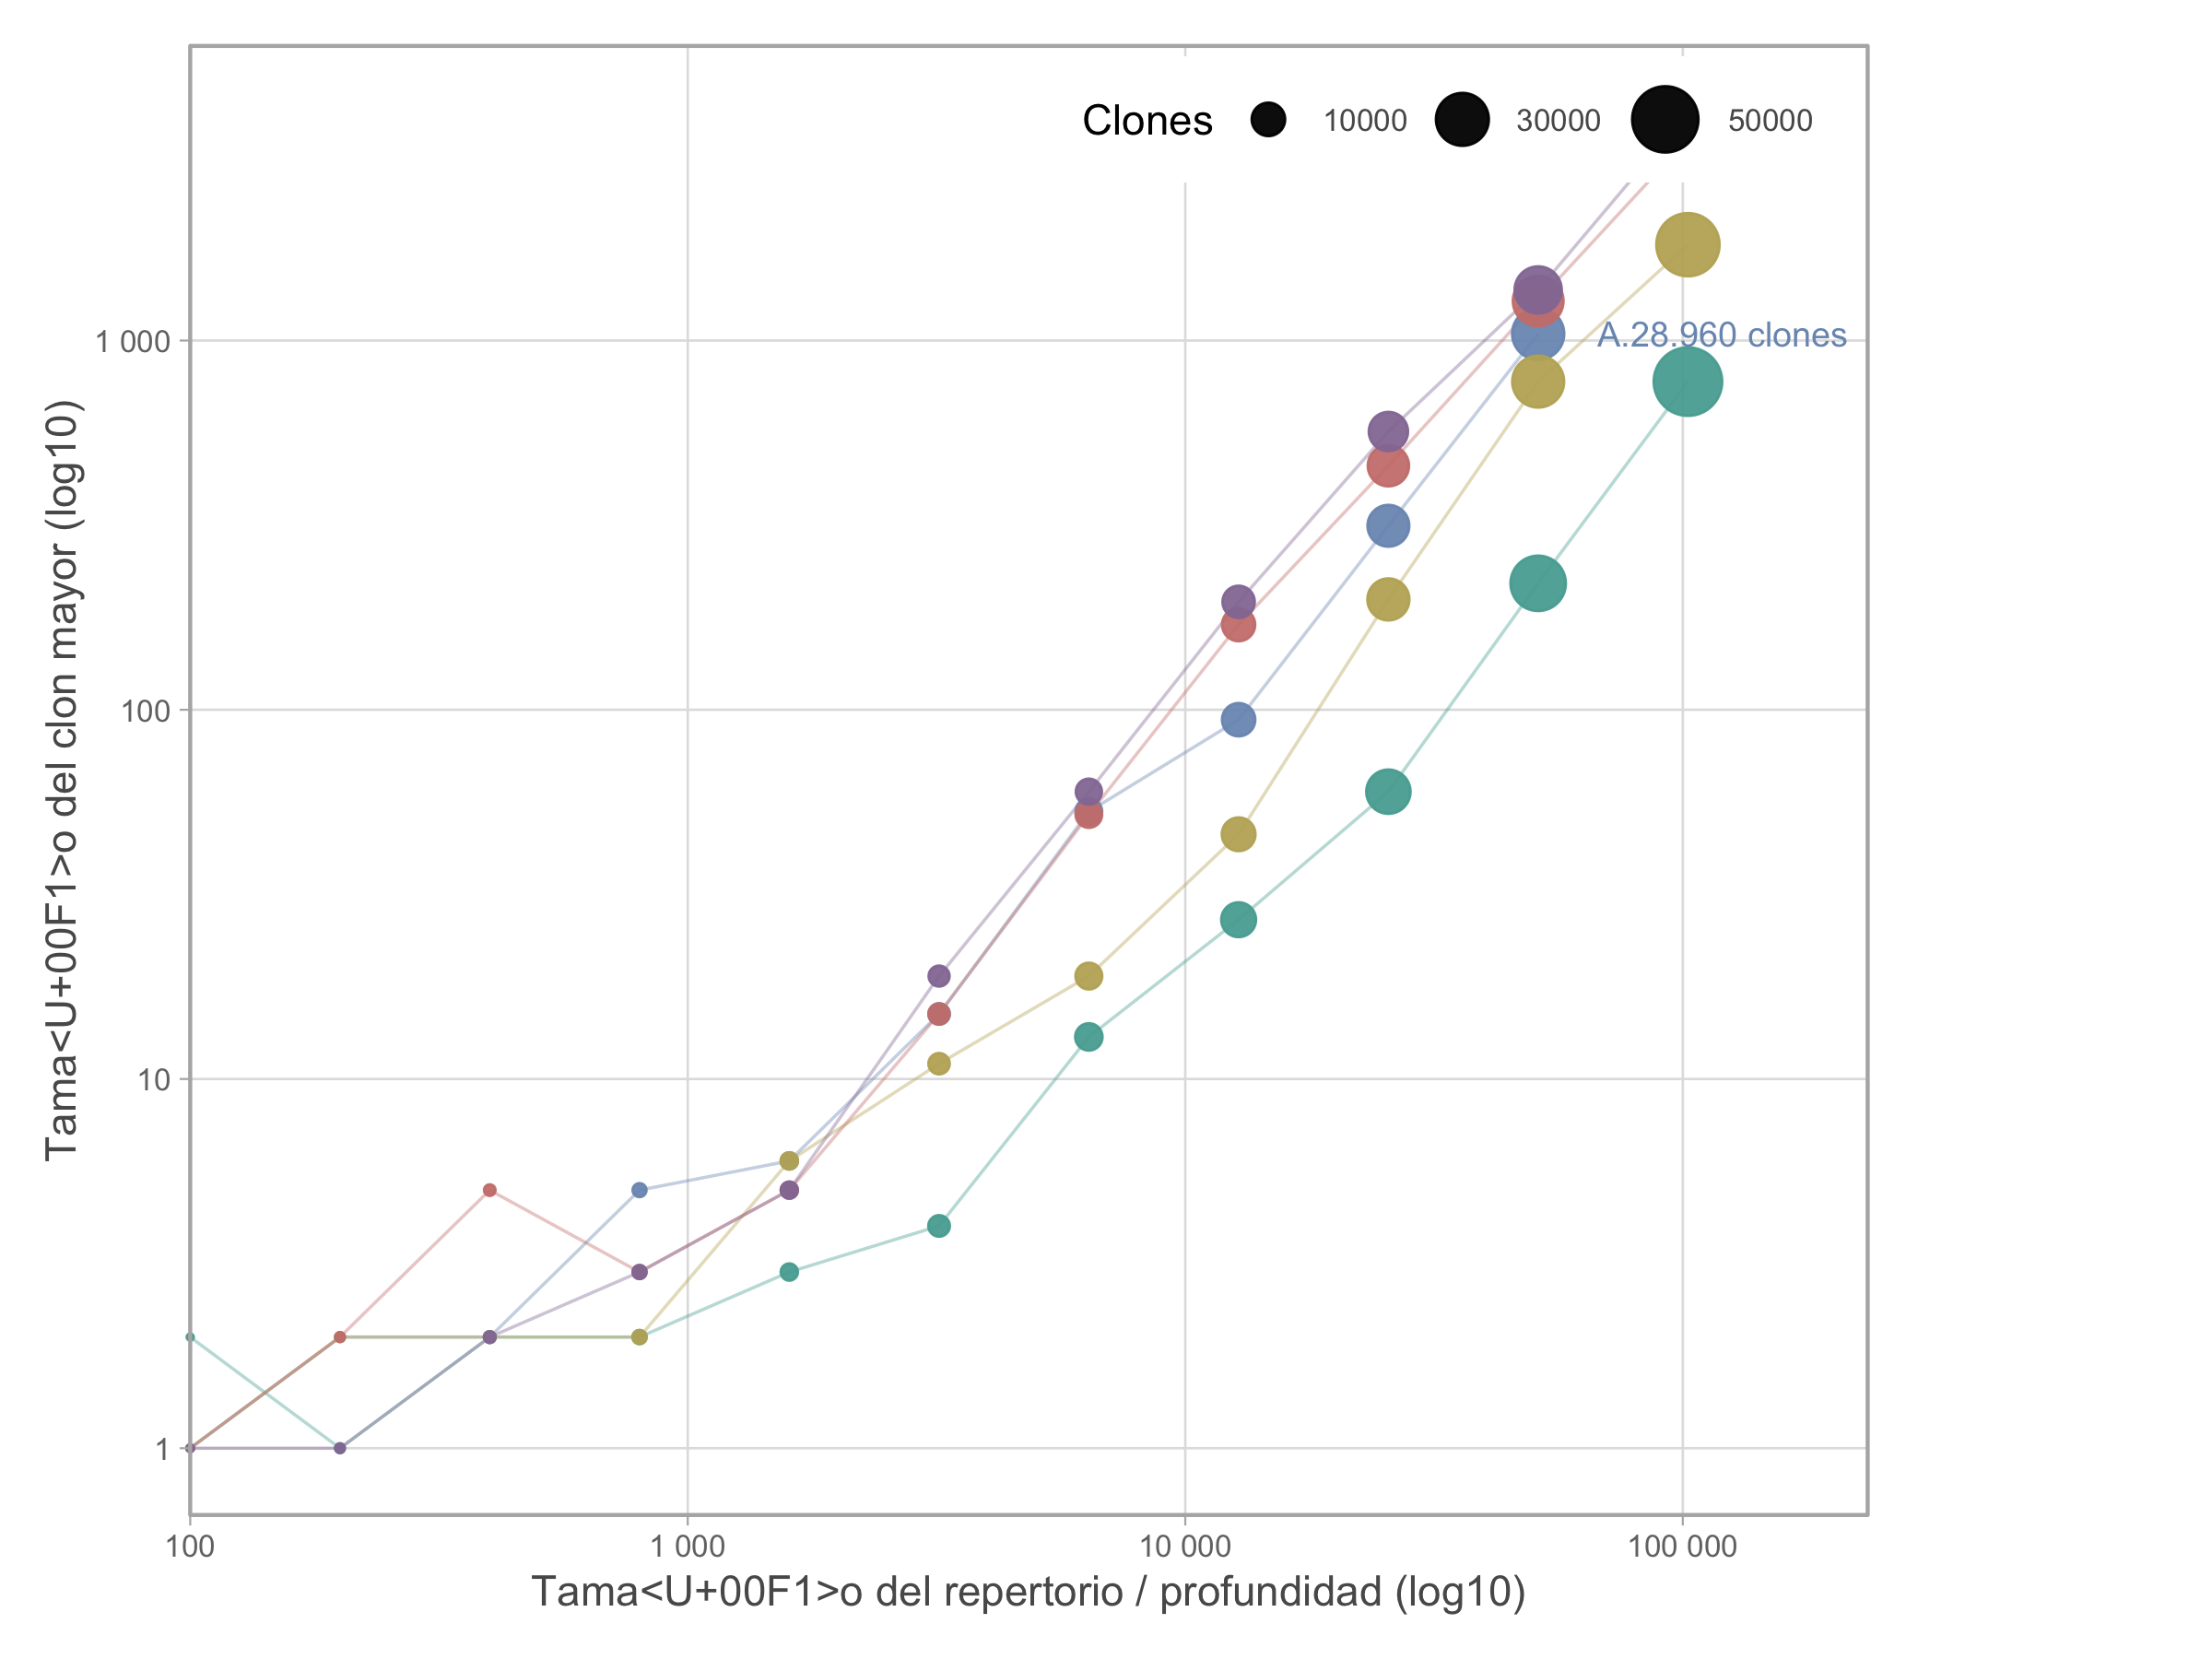

In [9]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)

colors <- c(A = "#7B98BE", B = "#58ABA2", C = "#BFAF66", D = "#CD817C", E = "#957BA4")

theme(text = element_text(family = "Arial Unicode MS"))

ggplot(d, aes(x = profundidad, y = clon_mayor, color = escenario)) +
  geom_line(data = ~ filter(.x, completo), linewidth = 0.4, alpha = 0.4) +
  geom_point(data = ~ filter(.x, completo), aes(size = n_clones), alpha = 0.95) +
  geom_text(
    data = fin,
    aes(label = etiqueta),
    hjust = 0,
    nudge_x = 0.12,
    size = 3.2,
  ) +
  scale_x_log10(
    breaks = c(100, 1000, 10000, 100000),
    labels = c("100", "1 000", "10 000", "100 000"),
    limits = c(100, 102400),
    expand = expansion(mult = c(0, 0.12))
  ) +
  scale_y_log10(
    breaks = c(1, 10, 100, 1000, 10000),
    labels = c("1", "10", "100", "1 000", "10 000")
  ) +
  scale_size(
    range = c(0.5, 8),
    breaks = c(10000, 30000, 50000),
  ) +
  scale_color_manual(values = colors, guide = "none") +
  coord_cartesian(clip = "off") +
  labs(
    x = "Tamaño del repertorio / profundidad (log10)",
    y = "Tamaño del clon mayor (log10)",
    size = "Clones"
  ) +
  theme_light() +
  theme(
    plot.title = element_text(size = 9, colour = "grey35", hjust = 0, margin = margin(b = 14)),
    plot.margin = margin(12, 90, 12, 12),
    axis.title = element_text(colour = "grey35"),
    axis.text = element_text(size = 8, colour = "grey45"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey88", linewidth = 0.3),
    legend.position = "inside",
    legend.position.inside = c(0.75, 0.95),
    legend.direction = "horizontal",
    legend.text = element_text(size = 8, colour = "grey35"),
  )

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`)."


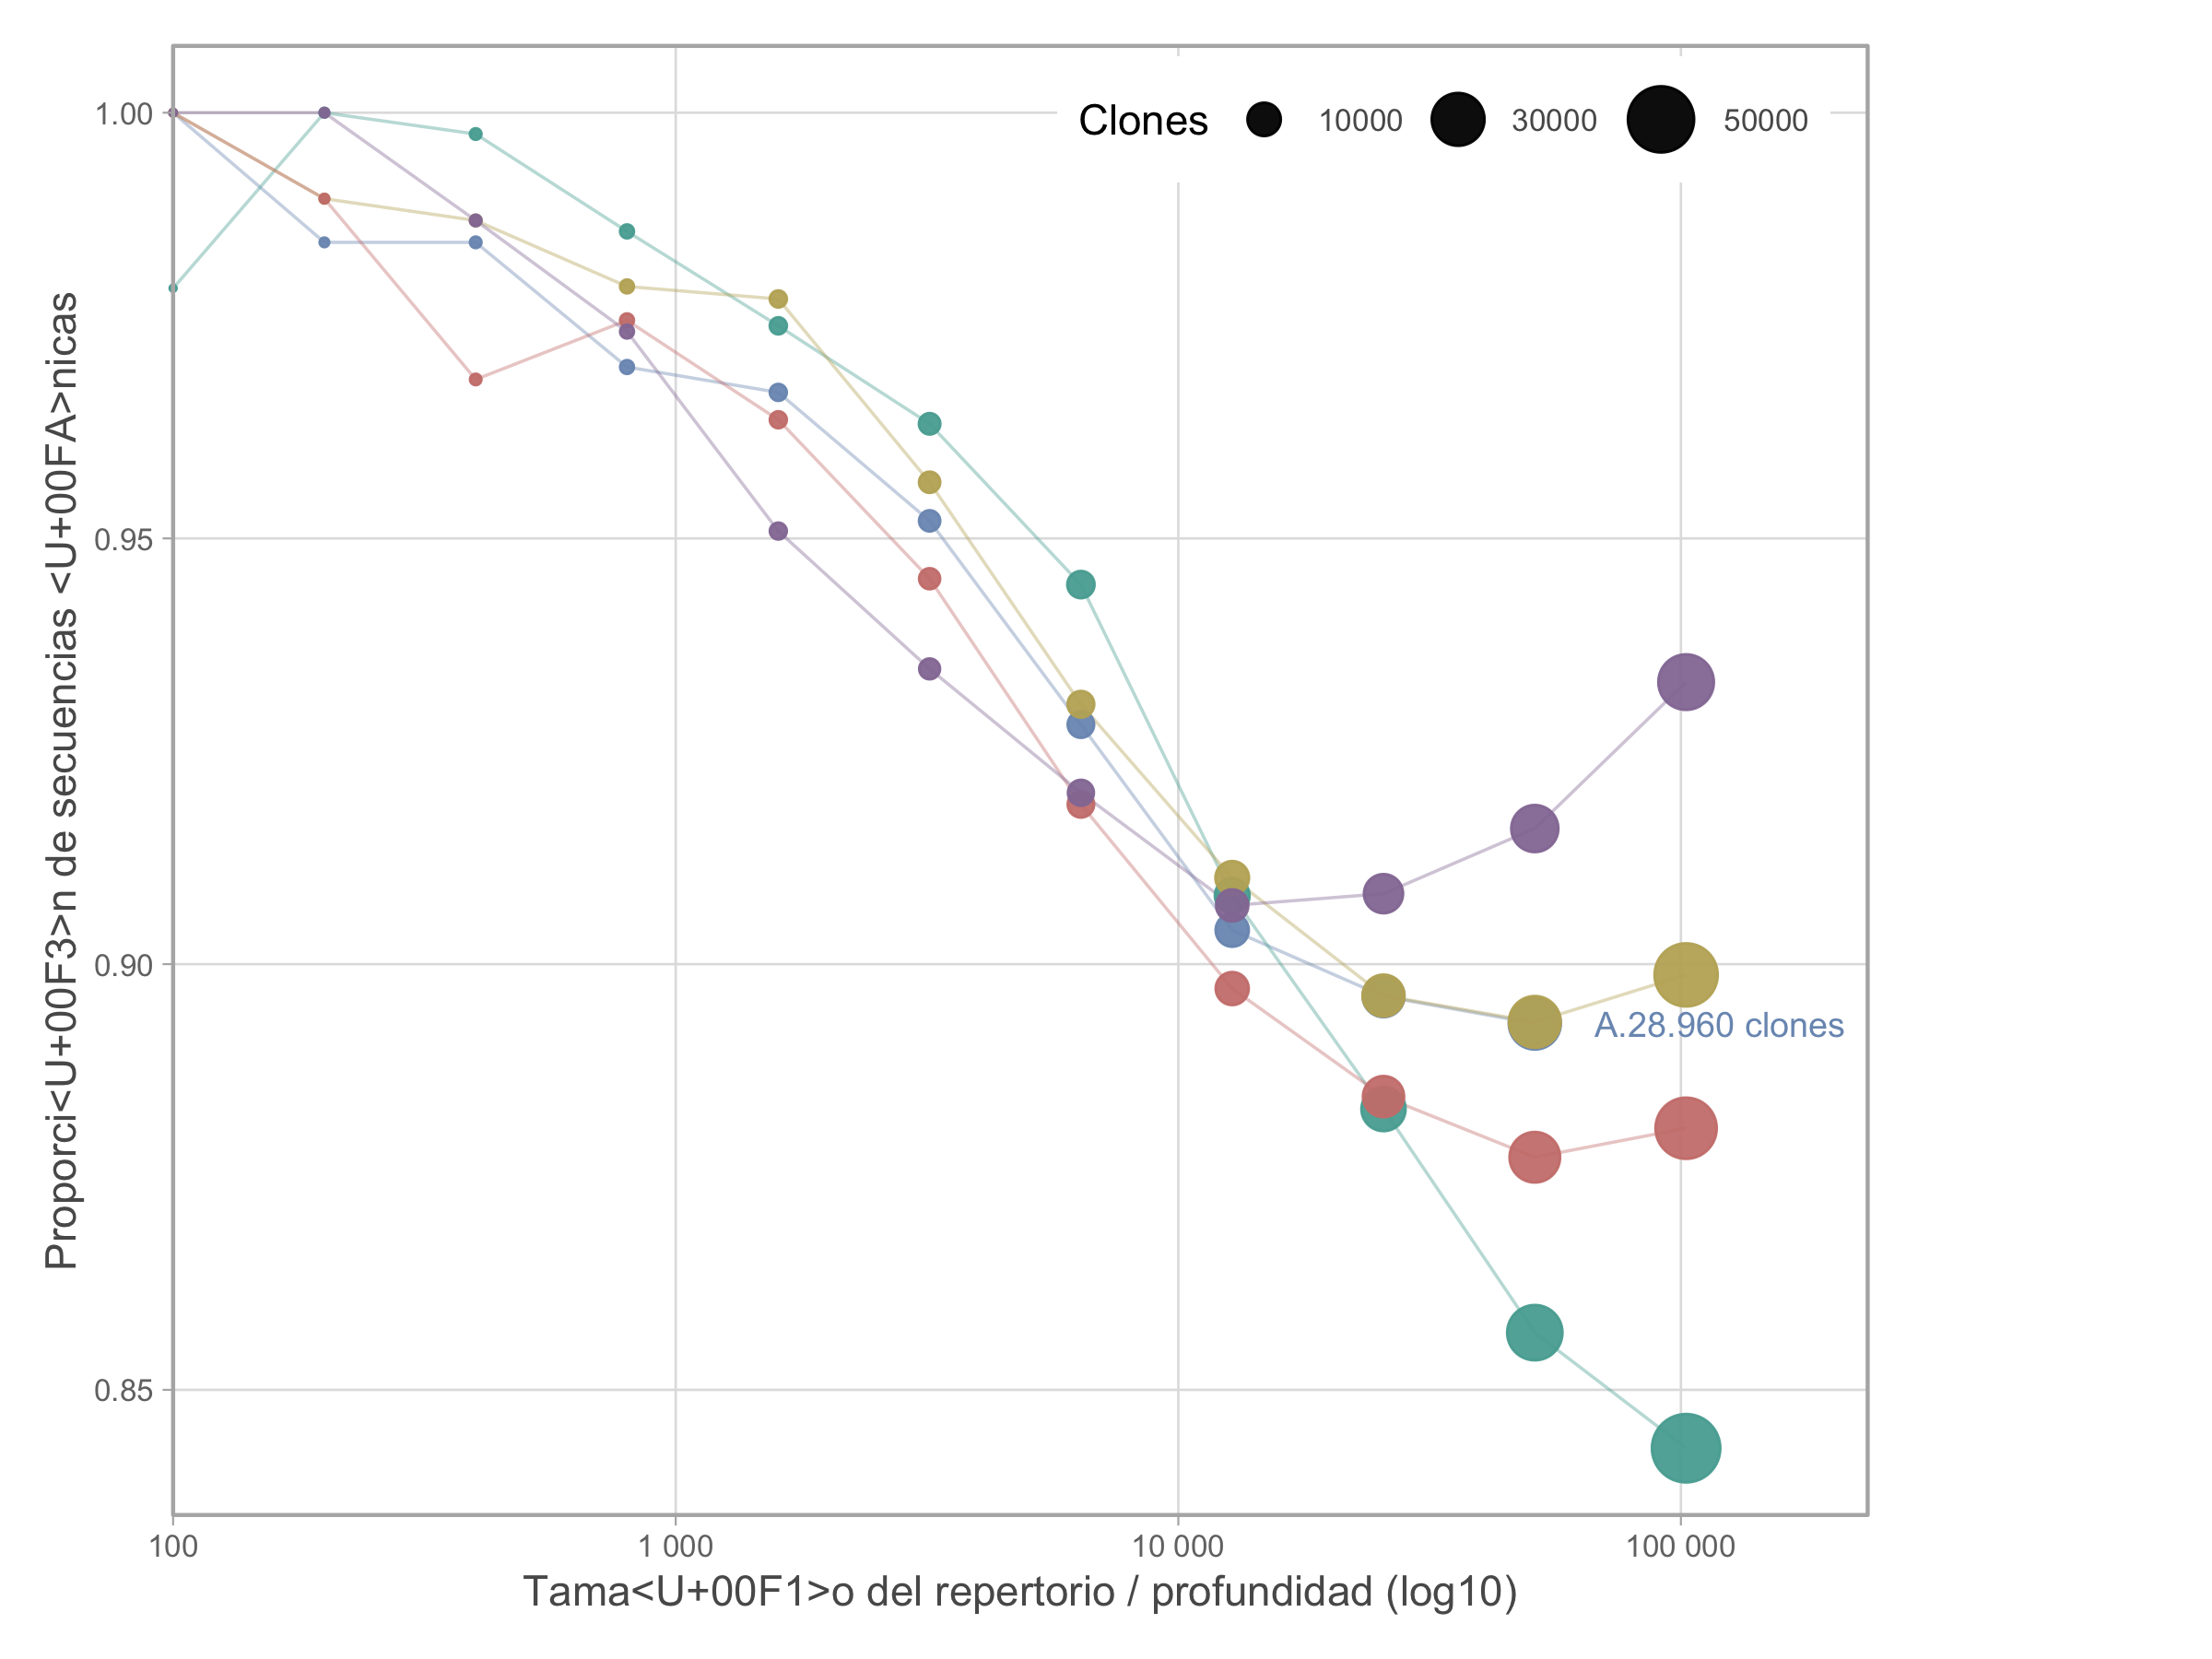

In [10]:

options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)

colors <- c(A = "#7B98BE", B = "#58ABA2", C = "#BFAF66", D = "#CD817C", E = "#957BA4")

ggplot(d, aes(x = profundidad, y = proporcion_singletons, color = escenario)) +
  geom_line(data = ~ filter(.x, completo), linewidth = 0.4, alpha = 0.4) +
  geom_point(data = ~ filter(.x, completo), aes(size = n_clones), alpha = 0.95) +
  geom_text(
    data = fin,
    aes(label = etiqueta),
    hjust = 0,
    nudge_x = 0.12,
    size = 3.2,
  ) +
  scale_x_log10(
    breaks = c(100, 1000, 10000, 100000),
    labels = c("100", "1 000", "10 000", "100 000"),
    limits = c(100, 102400),
    expand = expansion(mult = c(0, 0.12))
  ) +
  scale_size(
    range = c(0.5, 8),
    breaks = c(10000, 30000, 50000),
  ) +
  scale_color_manual(values = colors, guide = "none") +
  coord_cartesian(clip = "off") +
  labs(
    x = "Tamaño del repertorio / profundidad (log10)",
    y = "Proporción de secuencias únicas",
    size = "Clones"
  ) +
  theme_light() +
  theme(
    plot.title = element_text(size = 9, colour = "grey35", hjust = 0, margin = margin(b = 14)),
    plot.margin = margin(12, 90, 12, 12),
    axis.title = element_text(colour = "grey35"),
    axis.text = element_text(size = 8, colour = "grey45"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey88", linewidth = 0.3),
    legend.position = "inside",
    legend.position.inside = c(0.75, 0.95),
    legend.direction = "horizontal",
    legend.text = element_text(size = 8, colour = "grey35"),
  )